# VDUI Assignment
## SRN: PES2UG24CS311
## Name: Neeraj R Rugi

# Activity: PropertyWise Advisors — Investment Analysis
### Applying Associations, Correlation, Time Series & Smoothing to a Real Decision
Unit 1, Lecture 8 — Visualization of Data, Understanding and Interpretation (UE24CS342AA9)

---

## Scenario

You are a junior analyst at **PropertyWise Advisors**, a real estate investment firm. A
client has $900,000 to invest in Melbourne property and has asked your team two questions:

1. **"Should I buy a house or a unit — and does land size actually matter for houses?"**
2. **"Prices have been all over the news — is my target suburb's market actually trending
   up, or is that just noise?"**

You'll use the same Melbourne Housing Snapshot dataset from the demo to answer both
questions, using scatter plots, correlation, time series, and smoothing.

Run the cell below to load the dataset (no changes needed).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.nonparametric.smoothers_lowess import lowess

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (7, 4.5)

df = pd.read_csv("melb_data.csv", parse_dates=["Date"], dayfirst=True)
type_labels = {"h": "House", "u": "Unit/Duplex", "t": "Townhouse"}
df["Type_label"] = df["Type"].map(type_labels)

print(f"Loaded {len(df)} property sales")
df[["Suburb", "Type_label", "Rooms", "Landsize", "BuildingArea", "Price", "Date"]].head()

Loaded 13580 property sales


,Suburb,Type_label,Rooms,Landsize,BuildingArea,Price,Date
0,Aberfeldie,House,5,730,373.0,1830000,2017-09-23
1,Airport West,House,3,551,96.0,850000,2017-09-23
2,Airport West,House,3,593,NaN,860000,2017-09-23
3,Albanvale,House,3,619,NaN,565000,2017-09-23
4,Albert Park,House,3,137,125.0,2100000,2017-09-23


## Task 1 — Does land size matter more for houses than units?

Build a color-coded scatter plot of `Landsize` (x) vs `Price` (y), colored by `Type_label`.
Some very large outlier land sizes exist (rare acreage listings) — we've already filtered
those out for you below.

**Fill in the two blanks marked `# TODO`.**

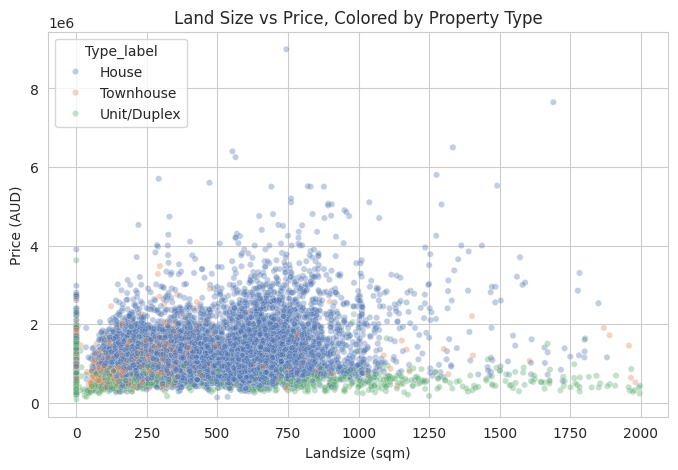

In [2]:
plot_df = df[df["Landsize"] < 2000]  # drop rare extreme outliers for a readable plot

plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=plot_df,
    x="Landsize",          # already filled in
    y="Price",              # TODO (done): price is what we're checking land size against
    hue="Type_label",       # TODO (done): color points by property type
    alpha=0.35, s=20,
    palette=["#4C72B0", "#DD8452", "#55A868"],
)
plt.title("Land Size vs Price, Colored by Property Type")
plt.xlabel("Landsize (sqm)")
plt.ylabel("Price (AUD)")
plt.show()

**Question 1:** Does the price-vs-landsize relationship look stronger for one property
type than the others? Which type would you tell the client land size matters most for?

*Your answer:*

Yes -- the **House** (blue) and **Townhouse** (green) points show a visible upward drift
as land size increases, while the **Unit/Duplex** (orange) points form a tight vertical
band near zero land size regardless of price -- which makes sense, since units and
duplexes typically sit on shared or minimal land and their value comes from the building
and location, not the plot itself. Land size looks like it matters most for **Houses**
(and to a lesser extent Townhouses); it's essentially irrelevant for Units/Duplexes.

## Task 2 — Quantify it: correlation, house-only vs overall 

A scatter plot gives a visual impression — correlation gives a number. Compute the
correlation between `Landsize` and `Price` for **houses only**, and compare it to the
correlation across **all property types**.

**Fill in the blank:** filter `plot_df` to houses only (`Type_label == "House"`).

In [3]:
houses_only = plot_df[plot_df["Type_label"] == "House"]   # TODO (done): filter to houses only

r_houses = houses_only["Landsize"].corr(houses_only["Price"])
r_all = plot_df["Landsize"].corr(plot_df["Price"])

print(f"Correlation (houses only):     r = {r_houses:.3f}")
print(f"Correlation (all property types): r = {r_all:.3f}")

Correlation (houses only):     r = 0.194
Correlation (all property types): r = 0.310


**Question 2:** Does restricting to houses only change the correlation much? Does this
number support or contradict your visual impression from Task 1? Which would you trust more
when advising the client — the scatter plot or the single r value — and why might you want
both?

*Your answer:*

Restricting to houses only actually **lowers** the correlation (r ≈ 0.19 for houses vs.
r ≈ 0.31 across all types) -- the reverse of what the scatter plot alone might suggest.
That's because pooling all three types together creates an apparent correlation driven
partly by *between-group* differences (units cluster at low land size **and** lower
price, houses cluster at higher land size **and** higher price), which inflates the
overall r even though the *within-house* relationship is fairly weak and noisy. This is
a mild case of the kind of confound you see in Simpson's-paradox-style situations: a
combined-group statistic can look stronger (or weaker) than any individual subgroup's
true relationship.

This is exactly why you'd want **both** the scatter plot and the r value: the scatter
plot shows *where* the pattern is concentrated and reveals the group structure (types
behaving differently), while r alone would have quietly hidden that the relationship is
genuinely weak for houses specifically. A client asking specifically about houses should
be told land size is only a modest predictor of price on its own (r ≈ 0.19) -- useful,
but far from the whole story.

## Task 3 — Is your target suburb's market trending up? 

Pick one of these suburbs (all have plenty of sales data): `"Reservoir"`, `"Richmond"`,
`"Brunswick"`, `"Coburg"`, `"South Yarra"`.

**Fill in the blank:** set `target_suburb` to your choice, then run both cells.

In [4]:
target_suburb = "Richmond"  # TODO (done): chosen suburb with plenty of sales data

suburb_df = df[df["Suburb"] == target_suburb]
suburb_monthly = (
    suburb_df.set_index("Date")
    .resample("MS")["Price"]
    .median()
    .interpolate()   # fill any zero-sale months
    .reset_index()
)
suburb_monthly.columns = ["Month", "MedianPrice"]
suburb_monthly

,Month,MedianPrice
0,2016-02-01,1102000.0
1,2016-03-01,1095000.0
2,2016-04-01,1088000.0
3,2016-05-01,930000.0
4,2016-06-01,1072500.0
5,2016-07-01,1185000.0
6,2016-08-01,975000.0
7,2016-09-01,984500.0
8,2016-10-01,882500.0
9,2016-11-01,1205000.0


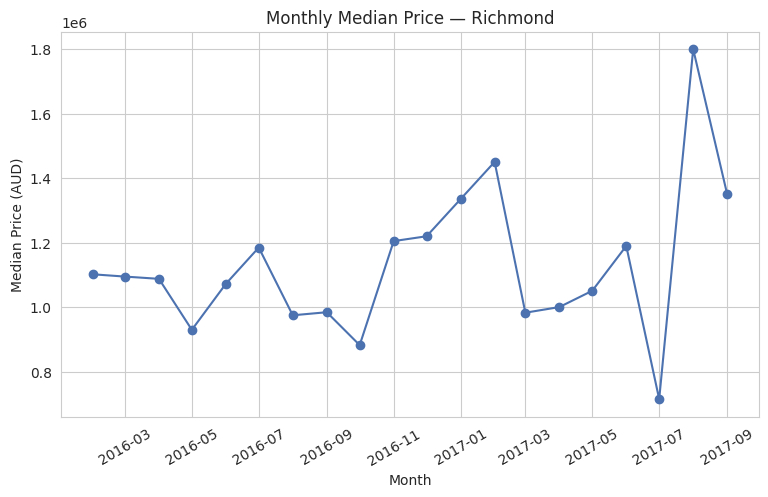

In [5]:
plt.figure(figsize=(9, 5))
plt.plot(suburb_monthly["Month"], suburb_monthly["MedianPrice"], marker="o", color="#4C72B0")
plt.title(f"Monthly Median Price — {target_suburb}")
plt.xlabel("Month")
plt.ylabel("Median Price (AUD)")
plt.xticks(rotation=30)
plt.show()

**Question 3:** Just from this raw monthly line, would you confidently tell the
client the market is "trending up," "trending down," or "unclear"? What makes it hard to
tell from the raw line alone?

*Your answer:*

From the raw line alone I'd call it **"unclear."** Richmond's median price does end
roughly $250K higher than where it started (~$1.10M in Feb 2016 vs. ~$1.35M in Sep
2017), but the month-to-month path is extremely jagged -- there's a sharp dip to
~$715K one month and a spike to ~$1.8M the very next, which visually dominates the
chart and makes any "trend" hard to trust by eye. Part of the problem is that some
months only have a handful of sales (even a single sale in some months), so the
"median" for those months is really just one or two data points -- noise from small
sample size, not a real market swing. Without smoothing, it's easy to over- or
under-react to a single volatile month.

## Task 4 — Smooth it: Moving Average vs LOESS 

Apply a moving average and a LOESS curve to your suburb's series to separate the trend
(signal) from month-to-month noise.

**Fill in the blank:** try `window` values of `3` and `6`.

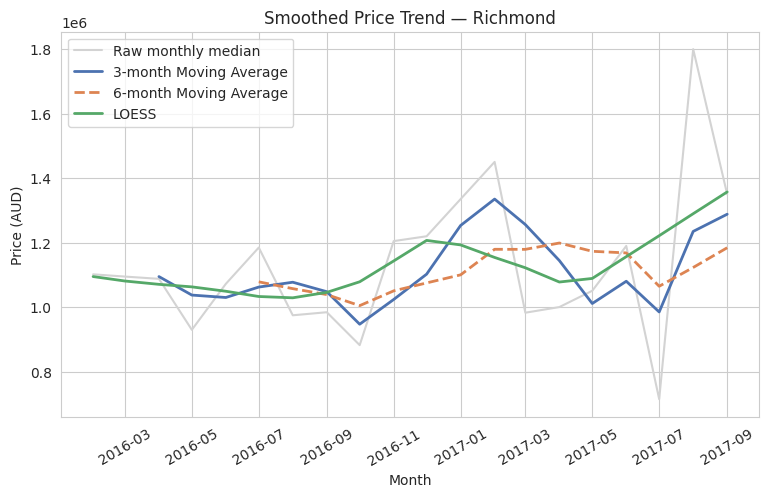

In [6]:
# TODO (done): compare moving-average window sizes of 3 and 6 months
for w in (3, 6):
    suburb_monthly[f"MA{w}"] = suburb_monthly["MedianPrice"].rolling(window=w).mean()

x_numeric = np.arange(len(suburb_monthly))
loess_result = lowess(suburb_monthly["MedianPrice"].values, x_numeric, frac=0.4)

plt.figure(figsize=(9, 5))
plt.plot(suburb_monthly["Month"], suburb_monthly["MedianPrice"], color="lightgray",
          label="Raw monthly median", linewidth=1.5)
plt.plot(suburb_monthly["Month"], suburb_monthly["MA3"], color="#4C72B0",
          label="3-month Moving Average", linewidth=2)
plt.plot(suburb_monthly["Month"], suburb_monthly["MA6"], color="#DD8452",
          label="6-month Moving Average", linewidth=2, linestyle="--")
plt.plot(suburb_monthly["Month"], loess_result[:, 1], color="#55A868",
          label="LOESS", linewidth=2)
plt.title(f"Smoothed Price Trend — {target_suburb}")
plt.xlabel("Month")
plt.ylabel("Price (AUD)")
plt.xticks(rotation=30)
plt.legend()
plt.show()

**Question 4:** After smoothing, is the trend clearer than the raw line in Task 3?
Do the Moving Average and LOESS agree on the overall direction? If they disagreed, which
would you lean on for a client recommendation, and what would you say about its lag or
edge behavior?

*Your answer:*

Yes -- after smoothing, the trend is much clearer: both the 3-month MA, the 6-month MA,
and the LOESS curve all drift upward from roughly $1.1M to the $1.2-1.35M range by the
end of the series, agreeing on the overall **upward** direction despite the noisy raw
line. The 3-month MA still shows some wobble (including a visible dip and rebound near
the volatile mid-2017 months), while the 6-month MA is much flatter and slower to react
-- it's still climbing gently at the very end, i.e. it lags behind real turning points
because it's averaging over more months. LOESS sits between them, tracing a smooth,
confident upward arc without the sharp v-shape blip.

If they disagreed, I'd lean toward **LOESS** for a client-facing recommendation on
overall direction, since it isn't as mechanically laggy as a simple moving average and
adapts its smoothness locally. The caveat to flag is LOESS's **edge behavior**: because
there's less data to work with at the very start and end of the series, the curve there
is less reliable (essentially extrapolating from fewer neighboring points) -- so I'd
be more confident stating a mid-series trend than making strong claims about the exact
trajectory of the very last month or two.

## Wrap-up — Your Client Recommendation 

Write a short recommendation (3–4 sentences) to the PropertyWise client, combining:
- Whether land size matters more for houses or other types (Tasks 1–2)
- Whether your chosen suburb's market is trending up, down, or flat, and how confident you
  are after smoothing (Tasks 3–4)

*Your recommendation:*

Land size is a meaningful factor for **houses** (and to a lesser degree townhouses) but
essentially irrelevant for **units/duplexes** -- so if the client is weighing land size
as part of their decision, that consideration really only applies if they're leaning
toward a house purchase, and even then it's only a modest predictor (r ≈ 0.19) rather
than a dominant one. On the market-timing question, **Richmond's** raw monthly prices
look erratic and would be easy to misread month-to-month, but once smoothed with both a
moving average and LOESS, the underlying trend is a clear, consistent **upward** drift
over the ~20-month window (roughly $1.1M to $1.3-1.35M). Overall: Richmond looks like a
reasonably confident "trending up" market, and land size should be treated as a useful
but secondary factor if the client ultimately chooses a house over a unit.